In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

In [54]:
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

数据介绍

bid_book_begin 集合竞价后的完整委托买入订单簿

ask_book_begin 集合竞价后的完整委托卖出订单簿

snap_list 连续竞价阶段的1s快照
    time_hms  时分秒字符串
    time_mark 毫秒级时间戳
    price_open 快照内首个成交价(无成交时为0.0)
    price_low  快照内最低成交价(无成交时为0.0)
    price_high 快照内最高成交价(无成交时为0.0)
    price_last 当日内最新成交价
     buy_trade 主动买入成交
    sell_trade 主动卖出成交
    bid_insert 委托买入挂单
    ask_insert 委托卖出挂单
    bid_cancel 委托买入撤单
    ask_cancel 委托卖出撤单

511520 511090 518880

In [55]:
import numpy as np
from typing import List, Dict, Any, Optional

class FeatureExtractor:
    def __init__(self, snap_slice: List[Dict[str, Any]], short_window: int = 60):
        if not snap_slice:
            raise ValueError("snap_slice cannot be empty")
        self.snap_slice = list(snap_slice)
        self.last = snap_slice[-1]
        self.bid_book = self.last.get('bid_book', [])
        self.ask_book = self.last.get('ask_book', [])
        self.short_window = short_window

        self.bid_volume = sum(vol for row in self.snap_slice for _, vol in row['buy_trade'])
        self.ask_volume = sum(vol for row in self.snap_slice for _, vol in row['sell_trade'])
        self.bid_volume_short = sum(vol for row in self.snap_slice[-self.short_window:] for _, vol in row['buy_trade'])
        self.ask_volume_short = sum(vol for row in self.snap_slice[-self.short_window:] for _, vol in row['sell_trade'])

    @staticmethod
    def _safe_get_level(book: List[tuple], idx: int = 0) -> tuple:
        if book and len(book) > idx:
            return book[idx]
        return (np.nan, 0)
    
    @property
    def price_last(self) -> float:
        return self.last.get('price_last', np.nan)
    
    @property
    def best_bid(self) -> float:
        return self._safe_get_level(self.bid_book)[0]
    
    @property
    def best_ask(self) -> float:
        return self._safe_get_level(self.ask_book)[0]
    
    @property
    def spread(self) -> float:
        bid, ask = self.best_bid, self.best_ask
        if np.isnan(bid) or np.isnan(ask):
            return np.nan
        return ask - bid
    
    @property
    def volatility(self) -> float:
        prices = [snap['price_last'] for snap in self.snap_slice 
                  if snap.get('price_last') is not None]
        if len(prices) < 2:
            return 0.0
        mean_price = np.mean(prices)
        if mean_price == 0:
            return 0.0
        return np.std(prices) / mean_price
    
    
    @property
    def wamp(self) -> float:
        bid_price, bid_vol = self._safe_get_level(self.bid_book)
        ask_price, ask_vol = self._safe_get_level(self.ask_book)
        numerator = bid_price * bid_vol + ask_price * ask_vol
        denominator = bid_vol + ask_vol
        if denominator == 0 or np.isnan(numerator):
            return 0.0
        return numerator / denominator
        
    @property
    def alpha_01(self) -> float:
        return self.bid_volume_short / self.bid_volume if self.bid_volume > 0 else 0.0

    @property
    def alpha_02(self) -> float:
        return self.ask_volume_short / self.ask_volume if self.ask_volume > 0 else 0.0
    
    @property
    def alpha_03(self) ->float:
        return (self.bid_volume_short - self.ask_volume_short) / (self.bid_volume + self.ask_volume) if (self.bid_volume + self.ask_volume) > 0 else 0.0
    
    @property
    def alpha_04(self) -> float:
        if len(self.snap_slice) < self.short_window:
            return 0.0
        num = self.snap_slice[-1]['num_trades'] - self.snap_slice[-self.short_window]['num_trades']
        return num / self.short_window if num > 0 else 0.0
    
    
    def extract_all(self) -> Dict[str, Any]:
        return {
            'price_last': self.price_last,
            'num_trades': self.last.get('num_trades', 0),
            'best_bid': self.best_bid,
            'best_ask': self.best_ask,
            'volatility': self.volatility,
            'spread': self.spread,
            'WAMP': self.wamp,
            'alpha_01': self.alpha_01,
            'alpha_02': self.alpha_02,
            'alpha_03': self.alpha_03,
            'alpha_04': self.alpha_04   
        }

def create_feature(snap_slice: List[Dict[str, Any]], short_window: int = 60) -> Dict[str, Any]:
    return FeatureExtractor(snap_slice, short_window).extract_all()

In [56]:
def latest_zscore(samples):
    if len(samples) == 0:
        return 0.0
    mean = np.mean(samples)
    std = np.std(samples)
    if std == 0:
        return 0.0
    return (samples[-1] - mean) / std

In [ ]:
import numpy as np
from scipy.stats import zscore

class TrainValidTest():
    def __init__(self, snap_list, param_dict, feature_func, y_func):
        if param_dict is not None:
            self.__dict__.update(param_dict)
        
        # 确保必要属性存在
        if not hasattr(self, 'x_window'):
            self.x_window = 1
        if not hasattr(self, 'y_window'):
            self.y_window = 1
        if not hasattr(self, 'short_window'):
            self.short_window = 5
        if not hasattr(self, 'long_window'):
            self.long_window = 20

        self.snap_list = snap_list.copy()
        self.create_feature = feature_func
        self.create_y = y_func

        # per second bid_volume and ask_volume
        bid_volume = [sum(vol for _, vol in row['buy_trade']) for row in self.snap_list]
        ask_volume = [sum(vol for _, vol in row['sell_trade']) for row in self.snap_list]
        bid_arr = np.array(bid_volume)
        ask_arr = np.array(ask_volume)
        self.delta = (bid_arr - ask_arr).tolist()


    def samples(self):
        feature_records = []   # 存放特征字典
        labels = []            # 存放标签（标量）
        n = len(self.snap_list)
        stride = getattr(self, 'stride', 1)

        for i in range(self.x_window, n - self.y_window, stride):
            flag, category = self.trigger(i)
            if not flag:
                continue
            x_dict = self.create_feature(self.snap_list[i - self.x_window:i], self.short_window)

            volatility = x_dict.get('volatility', 0.0)
            y_val = self.create_y(
                self.snap_list[i:i + self.y_window],
                volatility, self.k_up, self.k_down, category
            )
            feature_records.append(x_dict)
            labels.append(y_val)

        if not feature_records:
            return pd.DataFrame(), pd.Series(dtype=float)

        X_all = pd.DataFrame(feature_records)
        y_all = pd.Series(labels)
        return X_all, y_all

    def trigger(self, time):
        std_delta = latest_zscore(self.delta[time - self.short_window:time])

        if std_delta > self.open_threshold:
            return True, 1
        elif std_delta < -self.open_threshold:
            return True, -1
        else:
            return False , 0

def samples_from_dates(dates, instrument_id, param_dict, create_feature, create_y):
    X_all_list = []
    y_all_list = []
    
    for date in dates:
        try:
            snap_list = base_tool.snap_list_load(instrument_id, date)
            if len(snap_list) < param_dict['x_window'] + param_dict['y_window']:
                print(f"{date}: 数据不足，跳过")
                continue
            tv = TrainValidTest(snap_list, param_dict, create_feature, create_y)
            X_day, y_day = tv.samples()
            X_all_list.append(X_day)
            y_all_list.append(y_day)
            print(f"{date}: 产生 {len(X_day)} 个样本")
        except Exception as e:
            print(f"{date}: 加载失败 - {e}")
    
    if X_all_list:
        X_total = pd.concat(X_all_list, axis=0, ignore_index=True)
        y_total = pd.concat(y_all_list, axis=0, ignore_index=True)
    else:
        X_total = pd.DataFrame()
        y_total = pd.Series()
    
    return X_total, y_total

def create_y(snap_slice, volatility, k_up, k_down,category):
    # 初始化突破时间索引为 None
    t_up = None
    t_down = None

    start = snap_slice[0]['price_last']
    if start is None or start == 0 or pd.isna(start):
        return 0

    up = start * (1 + volatility * k_up)
    down = start * (1 - volatility * k_down)

    for i in range(1, len(snap_slice)):
        price = snap_slice[i]['price_last']
        if price is None or pd.isna(price):
            continue

        if t_up is None and price >= up:
            t_up = i
        if t_down is None and price <= down:
            t_down = i

        if t_up is not None and t_down is not None:
            break

    # 根据触发情况决定标签
    if t_up is not None and t_down is not None:
        label = 1 if t_up < t_down else -1
    elif t_up is not None:
        label = 1
    elif t_down is not None:
        label = -1
    else:
        label = 0

    if category == label:
        label = 1
    else:
        label = 0

    return label





In [ ]:
from collections import deque
import itertools
import os
import pandas as pd
from typing import Dict, Any

class StrategyDemo():
    def __init__(self, model, param_dict=None) -> None:
        if param_dict is None:
            param_dict = {}
        self.__dict__.update(param_dict)
        
        data_file = f'/home/jovyan/work/backtest_result/{self.instrument_id}_{self.trade_ymd}_{self.name}.pkl'
        try:
            if os.path.exists(data_file):
                os.remove(data_file)
        except OSError as e:
            print(f"Warning: Could not delete file {data_file}: {e}")

        self.position_last = 0
        self.model = model
        
        
        self.feature_buffer = deque(maxlen=self.x_window)
        self.delta_buffer = deque(maxlen=self.x_window)  
        
        self.prev_signal = 0

    def on_snap(self, snap: Dict[str, Any]) -> None:
        price = snap.get('price_last')
        if not price:
            return

        delta = sum(vol for _, vol in snap['buy_trade']) - sum(vol for _, vol in snap['sell_trade'])
        self.delta_buffer.append(delta)
        if len(self.delta_buffer) < self.x_window:
            return

        # 使用 itertools.islice 避免创建新列表
        recent_delta = list(itertools.islice(self.delta_buffer, max(0, len(self.delta_buffer) - self.short_window), None))
        std_delta = latest_zscore(recent_delta)
        # ---------- 特征工程（保持原逻辑）----------
        self.feature_buffer.append(snap)
        if len(self.feature_buffer) == self.x_window:
            feat_dict = create_feature(self.feature_buffer, self.short_window)   # 需要事先定义
            features_df = pd.DataFrame([feat_dict])
            prob = self.model.predict_proba(features_df)[:, 1][0]
        else:
            return   # 特征不足，不产生信号

        # ---------- 信号生成 ----------
        if std_delta > self.open_threshold:
            current_signal = 1
        elif std_delta < -self.open_threshold:
            current_signal = -1
        elif abs(std_delta) < self.close_threshold :
            current_signal = 0
        else:
            current_signal = self.prev_signal

        if current_signal != self.prev_signal:
            if current_signal == 0:
                self.position_last = 0
                self.prev_signal = 0
            else:
                if prob > self.confidence_threshold:
                    self.position_last = current_signal
                    self.prev_signal = current_signal

In [59]:
instrument_id = '518880'
trade_ymd = '20260319'

In [ ]:
param_dict = {

    'instrument_id' : instrument_id,
    'trade_ymd' : trade_ymd,
    
    'short_window' : 60 ,
    'long_window' : 300 , 
    'threshold' : 2 ,
    'confidence_threshold' : 0.8 ,
    'name' : 'delta_v1',

    'y_window' : 300 ,
    'stride': 1,

    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'],param_dict['long_window'])


In [61]:
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, classification_report

train_days = 35
valid_days = 9
test_days = 10

trade_dates = ["20260105"
,"20260106"
,"20260107"
,"20260108"
,"20260109"
,"20260112"
,"20260113"
,"20260114"
,"20260115"
,"20260116"
,"20260119"
,"20260120"
,"20260121"
,"20260122"
,"20260123"
,"20260126"
,"20260127"
,"20260128"
,"20260129"
,"20260130"
,"20260202"
,"20260203"
,"20260204"
,"20260205"
,"20260206"
,"20260209"
,"20260210"
,"20260211"
,"20260212"
,"20260213"
,"20260224"
,"20260225"
,"20260226"
,"20260227"
,"20260302"
,"20260303"
,"20260304"
,"20260305"
,"20260306"
,"20260309"
,"20260310"
,"20260311"
,"20260312"
,"20260313"
,"20260316"
,"20260317"
,"20260318"
,"20260319"
,"20260320"
,"20260323"
,"20260324"
,"20260325"
,"20260326"
,"20260327"]
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

总交易日数量: 54
交易日范围: 20260105 ~ 20260327


In [62]:
train_dates = trade_dates[:train_days]
valid_dates = trade_dates[train_days:train_days + valid_days]
test_dates = trade_dates[train_days + valid_days:train_days + valid_days + test_days]

print(f"训练集: {train_dates[0]} ~ {train_dates[-1]} ({len(train_dates)}天)")
print(f"验证集: {valid_dates[0]} ~ {valid_dates[-1]} ({len(valid_dates)}天)")
print(f"测试集: {test_dates[0]} ~ {test_dates[-1]} ({len(test_dates)}天)")

训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


In [63]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(27632, 11), y=(27632,)
标签分布:
0    19665
1     7967
Name: count, dtype: int64


In [64]:
%%time
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
验证集样本: X=(7126, 11), y=(7126,)
标签分布:
0    4995
1    2131
Name: count, dtype: int64
CPU times: user 6.04 s, sys: 16 ms, total: 6.05 s
Wall time: 6.05 s


In [65]:
%%time
scale_pos_weight_value = (y_train == 0).sum() / (y_train != 0).sum() if (y_train != 0).sum() > 0 else 1.0
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=10
)

[0]	validation_0-logloss:0.69260
[10]	validation_0-logloss:0.68900
[20]	validation_0-logloss:0.68657
[30]	validation_0-logloss:0.68312
[40]	validation_0-logloss:0.68049
[50]	validation_0-logloss:0.67773
[60]	validation_0-logloss:0.67510
[70]	validation_0-logloss:0.67267
[80]	validation_0-logloss:0.67070
[90]	validation_0-logloss:0.66883
[100]	validation_0-logloss:0.66732
[110]	validation_0-logloss:0.66590
[120]	validation_0-logloss:0.66442
[130]	validation_0-logloss:0.66312
[140]	validation_0-logloss:0.66205
[150]	validation_0-logloss:0.66110
[160]	validation_0-logloss:0.66024
[170]	validation_0-logloss:0.65911
[180]	validation_0-logloss:0.65825
[190]	validation_0-logloss:0.65751
[200]	validation_0-logloss:0.65632
[210]	validation_0-logloss:0.65502
[220]	validation_0-logloss:0.65426
[230]	validation_0-logloss:0.65357
[240]	validation_0-logloss:0.65241
[250]	validation_0-logloss:0.65174
[260]	validation_0-logloss:0.65095
[270]	validation_0-logloss:0.64997
[280]	validation_0-logloss:0.64

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

验证集准确率: 0.6690017513134852
分类报告:
              precision    recall  f1-score   support

      不可信(0)       0.75      0.77      0.76       386
       可信(1)       0.49      0.45      0.47       185

    accuracy                           0.67       571
   macro avg       0.62      0.61      0.61       571
weighted avg       0.66      0.67      0.67       571

In [66]:
y_pred = model.predict(X_valid)
print("验证集准确率:", accuracy_score(y_valid, y_pred))

unique_labels = sorted(set(y_valid.unique()) | set(np.unique(y_pred)))
label_names = { 0: '不可信(0)', 1: '可信(1)' }
target_names = [label_names.get(l, str(l)) for l in unique_labels]
print("分类报告:")
print(classification_report(y_valid, y_pred, labels=unique_labels, target_names=target_names))

验证集准确率: 0.6413134998596688
分类报告:
              precision    recall  f1-score   support

      不可信(0)       0.78      0.67      0.73      4995
       可信(1)       0.42      0.56      0.48      2131

    accuracy                           0.64      7126
   macro avg       0.60      0.62      0.60      7126
weighted avg       0.68      0.64      0.65      7126



In [67]:
model_path = f'/home/jovyan/work/backtest_result/{instrument_id}_xgb_model.pkl'
joblib.dump(model, model_path)
print(f"模型已保存至: {model_path}")


模型已保存至: /home/jovyan/work/backtest_result/518880_xgb_model.pkl


# 测试集表现

In [68]:
%%time
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...


20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(8037, 11), y=(8037,)
CPU times: user 7.46 s, sys: 32 ms, total: 7.49 s
Wall time: 7.49 s


In [69]:
import os
import sys
current_notebook_path = os.path.abspath('%pwd') 
current_dir = os.path.dirname(current_notebook_path)
parent_dir = os.path.dirname(current_dir)
utils_path = os.path.join(parent_dir, 'tools')
sys.path.append(utils_path)

日期 20260303 回测完成，当日盈亏: -9.30
日期 20260304 回测完成，当日盈亏: -8.90
日期 20260305 回测完成，当日盈亏: -7.90
日期 20260306 回测完成，当日盈亏: -22.70

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20

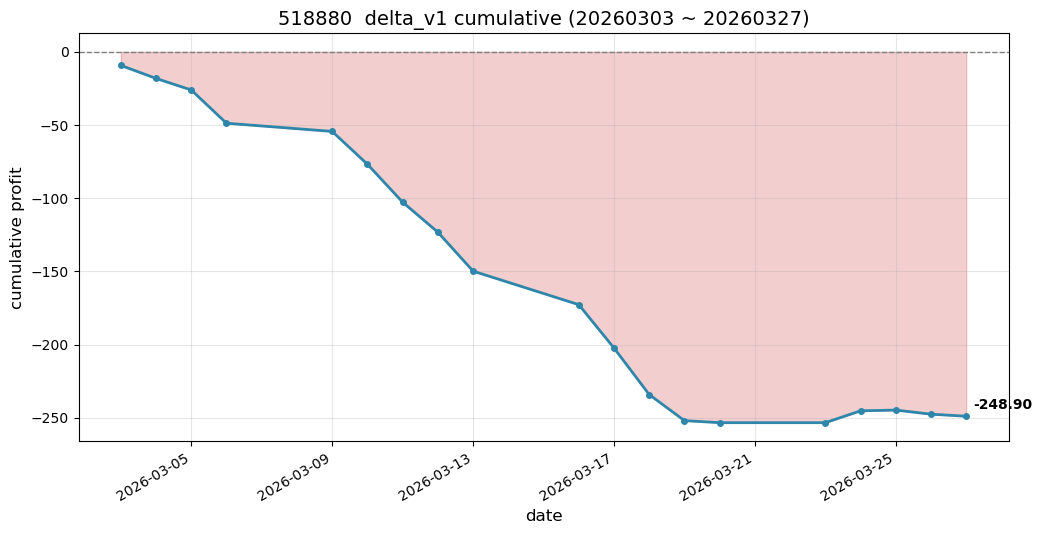

In [71]:
from backtesting import backtest_multi_days
param_dict['trade_ymd'] = ''
strategy = StrategyDemo(model,param_dict)
backtest_df = backtest_multi_days(instrument_id,'20260303','20260327',strategy,param_dict)

In [72]:
backtest_df

,trade_ymd,time_mark,time_hms,price_last,position,trade_price,trade,trade_cost,realized_pnl,unrealized_pnl,profits,position_value,trade_date
0,20260303,汇总,汇总,0.0,0,0.0,0,0.0,-9.3,0.0,-9.3,0.0,2026-03-03
1,20260304,汇总,汇总,0.0,0,0.0,0,0.0,-8.9,0.0,-8.9,0.0,2026-03-04
2,20260305,汇总,汇总,0.0,0,0.0,0,0.0,-7.9,0.0,-7.9,0.0,2026-03-05
3,20260306,汇总,汇总,0.0,-1,0.0,0,0.0,-22.8,0.1,-22.7,1087.3,2026-03-06
4,20260309,汇总,汇总,0.0,0,0.0,0,0.0,-5.6,0.0,-5.6,0.0,2026-03-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,20260323,汇总,汇总,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,2026-03-23
15,20260324,汇总,汇总,0.0,1,0.0,0,0.0,0.0,8.1,8.1,930.1,2026-03-24
16,20260325,汇总,汇总,0.0,0,0.0,0,0.0,0.5,0.0,0.5,0.0,2026-03-25
17,20260326,汇总,汇总,0.0,0,0.0,0,0.0,-2.8,0.0,-2.8,0.0,2026-03-26


# 过去回测

In [ ]:
backtest_df

,trade_ymd,order_time,order_price,total,trade,cancel,hold,profit_last,profits,maxdd,MAR,pper,trade_date
0,20260303,2026-03-03 13:26:24,11.358,112,110,2,0,-0.2,-5.8,5.8,-1.00,-0.05,2026-03-03
1,20260304,2026-03-04 13:30:06,10.998,2,2,0,0,-0.2,-0.2,1.0,-0.20,-0.10,2026-03-04
2,20260305,2026-03-05 14:55:00,10.949,32,32,0,0,-4.1,-6.0,6.0,-1.00,-0.19,2026-03-05
3,20260306,2026-03-06 14:39:37,10.886,48,47,1,0,-0.2,1.9,3.0,0.63,0.04,2026-03-06
4,20260311,2026-03-11 14:13:15,10.990,234,232,2,0,-0.1,-12.8,12.8,-1.00,-0.06,2026-03-11
5,20260312,2026-03-12 14:39:27,10.931,31,31,0,0,-0.1,-2.4,2.4,-1.00,-0.08,2026-03-12
6,20260313,2026-03-13 14:55:00,10.798,89,88,1,0,3.6,-0.2,3.8,-0.05,-0.00,2026-03-13
7,20260316,2026-03-16 14:40:11,10.681,125,123,2,0,-0.1,-12.0,12.0,-1.00,-0.10,2026-03-16
8,20260317,2026-03-17 14:55:00,10.637,237,233,4,0,-1.3,-13.1,13.1,-1.00,-0.06,2026-03-17
9,20260319,2026-03-19 14:15:14,10.274,135,133,2,0,-0.2,-5.7,5.7,-1.00,-0.04,2026-03-19


In [ ]:
from backtesting import backtest_summary
summary = backtest_summary(backtest_df)
print(summary)

{'交易天数': 14, '累计盈亏': np.float64(-42.1), '最大单日盈利': 17.2, '最大单日亏损': -13.1, '盈利天数': 2, '亏损天数': 12, '平盘天数': 0, '胜率(%)': np.float64(14.29), '日均盈亏': np.float64(-3.01), '盈亏比': np.float64(1.87), '交易次数': 1049, '平均交易盈利': np.float64(-0.04)}


In [ ]:

summary['short_window'] = param_dict['short_window']
summary['long_window'] = param_dict['long_window']
summary['threshold'] = param_dict['threshold']

In [ ]:
# add dict summary to outcome dataframe
df = pd.DataFrame()  
new_df = pd.DataFrame([summary])
df = pd.concat([df, new_df], ignore_index=True)

In [ ]:
print(df)

   交易天数  累计盈亏  最大单日盈利  最大单日亏损  盈利天数  亏损天数  平盘天数  胜率(%)  日均盈亏   盈亏比  交易次数  \
0    14 -42.1    17.2   -13.1     2    12     0  14.29 -3.01  1.87     0   

   平均交易盈利  short_window  long_window  threshold  
0       0            60          300          2  


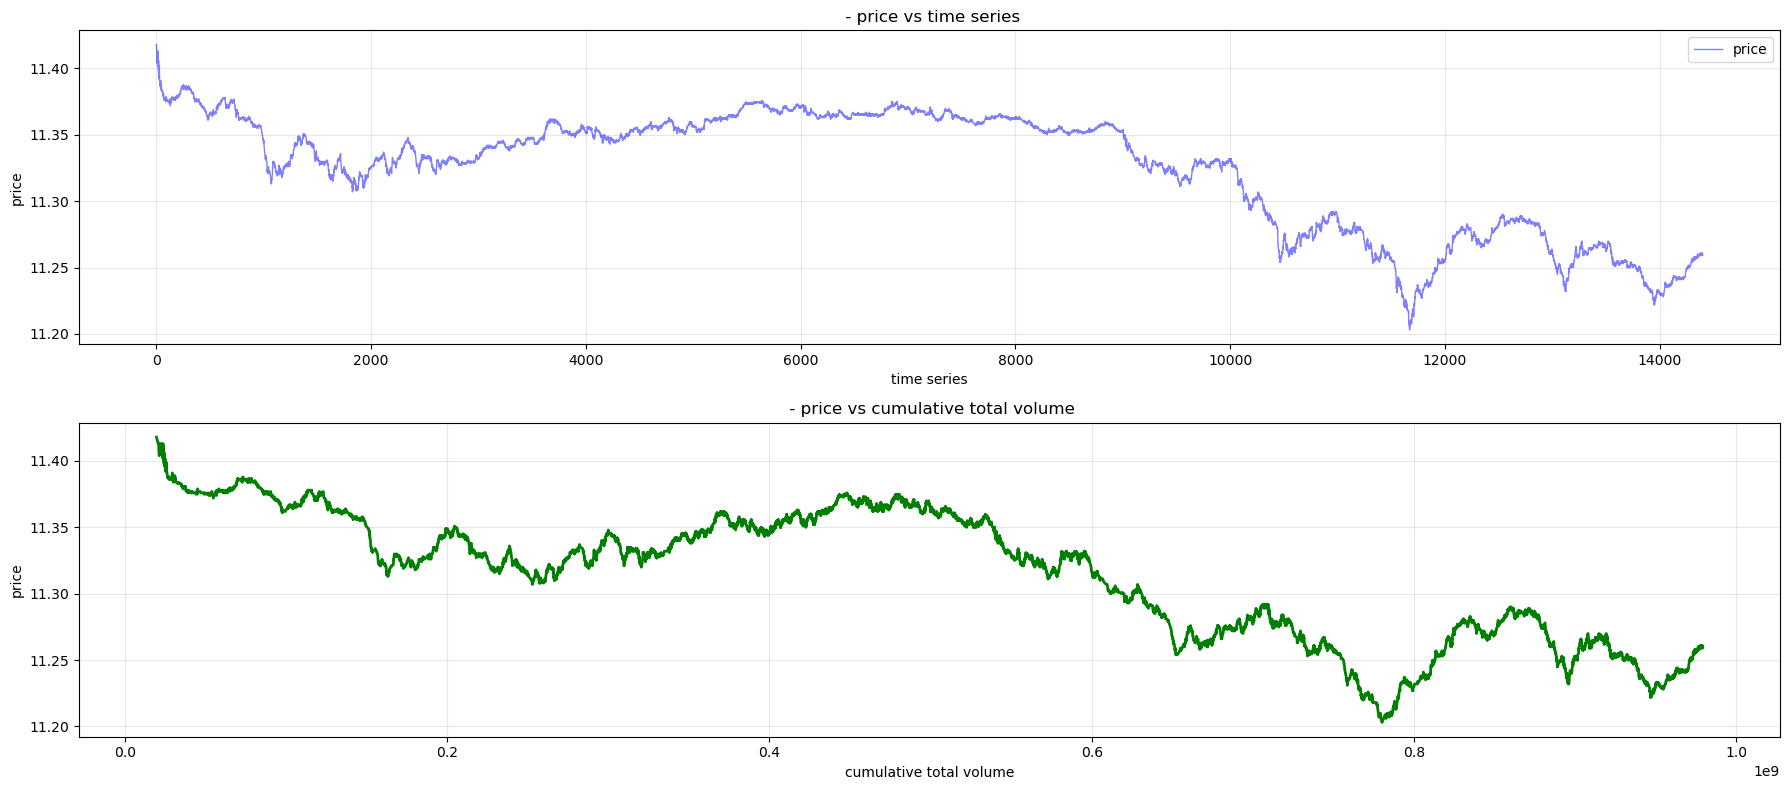

In [ ]:
from plot_price import plot_price_analysis
import matplotlib.pyplot as plt
  

snap_list = base_tool.snap_list_load(instrument_id, "20260303")
plot_price_analysis(snap_list)

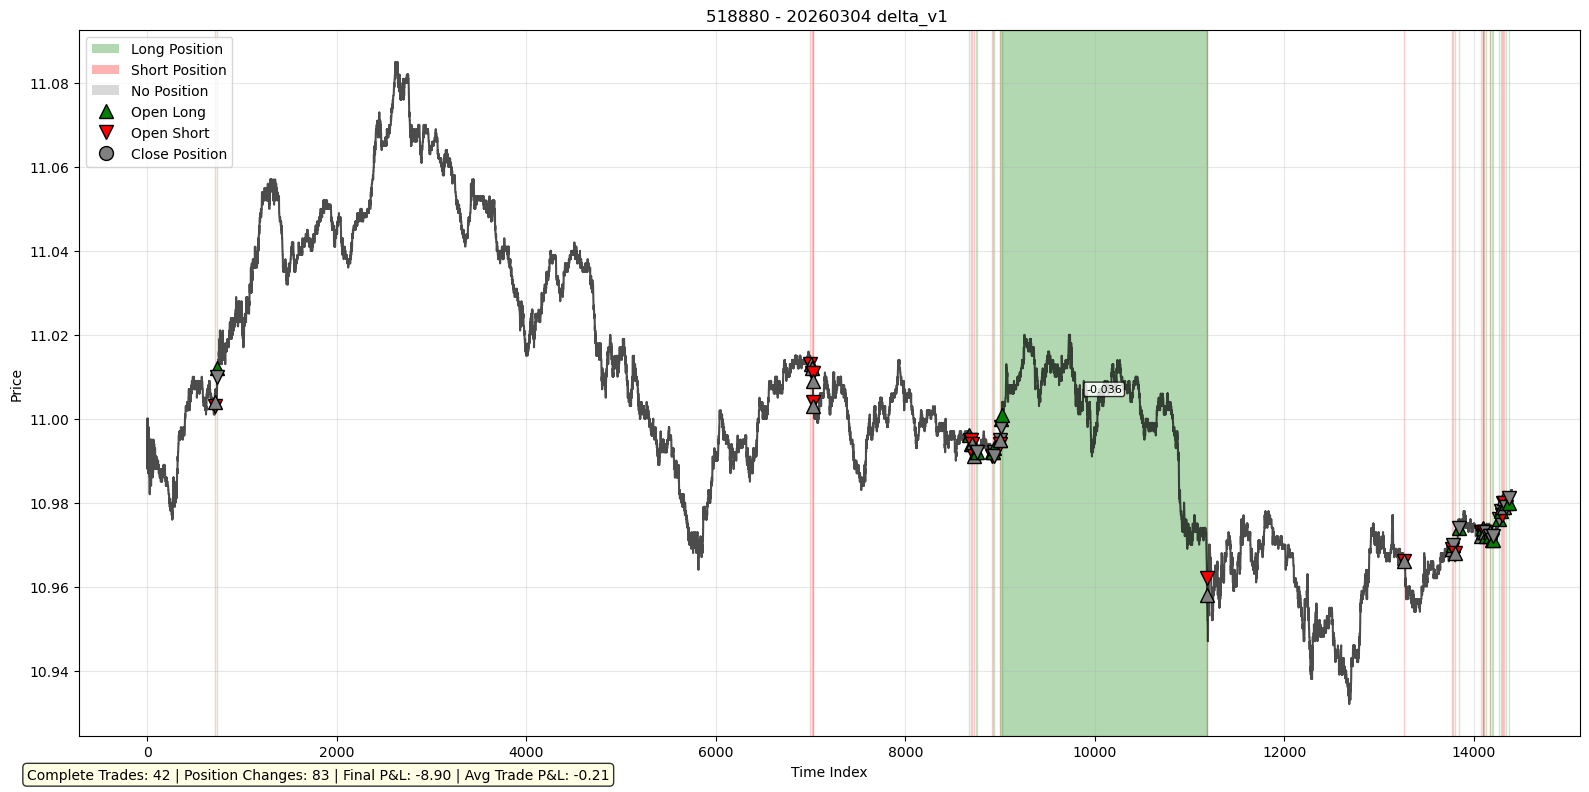

{'instrument_id': '518880',
 'trade_ymd': '20260304',
 'strategy_name': 'delta_v1',
 'snap_count': 14402,
 'position_changes': 83,
 'complete_trades': 42,
 'price_history': array([11.   , 10.988, 10.999, ..., 10.982, 10.982, 10.983],
       shape=(14402,)),
 'position_history': array([0, 0, 0, ..., 0, 0, 0], shape=(14402,)),
 'time_history': [1772587800000,
  1772587801000,
  1772587802000,
  1772587803000,
  1772587804000,
  1772587805000,
  1772587806000,
  1772587807000,
  1772587808000,
  1772587809000,
  1772587810000,
  1772587811000,
  1772587812000,
  1772587813000,
  1772587814000,
  1772587815000,
  1772587816000,
  1772587817000,
  1772587818000,
  1772587819000,
  1772587820000,
  1772587821000,
  1772587822000,
  1772587823000,
  1772587824000,
  1772587825000,
  1772587826000,
  1772587827000,
  1772587828000,
  1772587829000,
  1772587830000,
  1772587831000,
  1772587832000,
  1772587833000,
  1772587834000,
  1772587835000,
  1772587836000,
  1772587837000,
  177258783

In [76]:
from single_day_backtest import single_day_backtest

single_day_backtest(instrument_id , "20260304",strategy,param_dict)